# Perceptron and Adaline from Scratch

**Project 1 · Chapter 2 of *Machine Learning with PyTorch and Scikit-Learn***

**Goal:** implement the Perceptron and Adaline (batch gradient descent) in NumPy, train them on the Breast Cancer Wisconsin dataset, and compare them against scikit-learn and a majority-class baseline.

**Outline**
1. Load and explore the data
2. Split and standardize (no data leakage)
3. Baseline
4. Perceptron: training and convergence
5. Adaline: effect of the learning rate
6. Decision boundaries on two features
7. Comparison with scikit-learn (repeated over many splits)
8. Conclusions

In [1]:
import sys
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import Perceptron as SkPerceptron, SGDClassifier, LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

from models import Perceptron, AdalineGD  # our from-scratch implementations

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})
RANDOM_STATE = 1

## 1. Load and explore the data

In [2]:
data = load_breast_cancer()
X, y = data.data, data.target          # y: 0 = malignant, 1 = benign
feature_names = list(data.feature_names)

print("Samples:", X.shape[0], "| Features:", X.shape[1])
print("Class counts:", dict(zip(data.target_names.tolist(), np.bincount(y).tolist())))
pd.DataFrame(X, columns=feature_names).describe().T.head(8)

Samples: 569 | Features: 30
Class counts: {'malignant': 212, 'benign': 357}


,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,14.127292,3.524049,6.98100,11.70000,13.37000,15.7800,28.1100
mean texture,569.0,19.289649,4.301036,9.71000,16.17000,18.84000,21.8000,39.2800
mean perimeter,569.0,91.969033,24.298981,43.79000,75.17000,86.24000,104.1000,188.5000
mean area,569.0,654.889104,351.914129,143.50000,420.30000,551.10000,782.7000,2501.0000
mean smoothness,569.0,0.096360,0.014064,0.05263,0.08637,0.09587,0.1053,0.1634
mean compactness,569.0,0.104341,0.052813,0.01938,0.06492,0.09263,0.1304,0.3454
mean concavity,569.0,0.088799,0.079720,0.00000,0.02956,0.06154,0.1307,0.4268
mean concave points,569.0,0.048919,0.038803,0.00000,0.02031,0.03350,0.0740,0.2012


Feature scales differ by orders of magnitude (e.g. `mean area` is in the hundreds, `mean smoothness` is around 0.1). Gradient-based learners like Adaline are very sensitive to this, so we standardize.

## 2. Split and standardize
The scaler is fit on the **training set only**, then applied to the test set, so no test information leaks into training.

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=RANDOM_STATE
)

sc = StandardScaler().fit(X_train) # fit the scaler on the training data only
X_train_std = sc.transform(X_train) # standardize the training data
X_test_std = sc.transform(X_test) # standardize the test data using the same scaler

print("Train:", X_train_std.shape, "| Test:", X_test_std.shape)
print("Train class balance:", np.bincount(y_train) / len(y_train))

Train: (398, 30) | Test: (171, 30)
Train class balance: [0.3718593 0.6281407]


## 3. Baseline
Any model must beat a classifier that always predicts the majority class.

In [4]:
baseline = DummyClassifier(strategy="most_frequent").fit(X_train_std, y_train)
baseline_acc = accuracy_score(y_test, baseline.predict(X_test_std))
print(f"Majority-class baseline accuracy: {baseline_acc:.3f}")

Majority-class baseline accuracy: 0.626


## 4. Perceptron
The Perceptron updates its weights only when it misclassifies a sample. It converges only if the data is linearly separable, so the error count per epoch is a useful diagnostic.

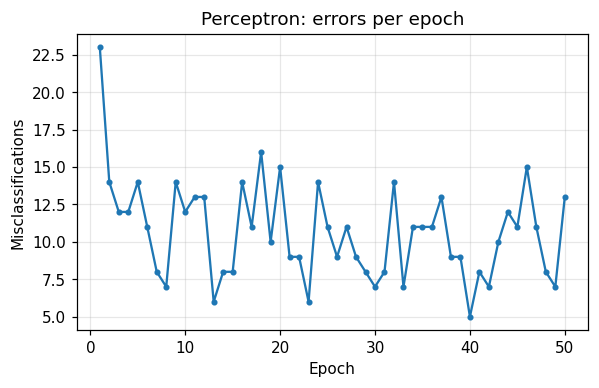

Perceptron test accuracy: 0.959


In [5]:
ppn = Perceptron(eta=0.01, n_iter=50, random_state=RANDOM_STATE).fit(X_train_std, y_train)

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.plot(range(1, len(ppn.errors_) + 1), ppn.errors_, marker="o", ms=3)
ax.set(xlabel="Epoch", ylabel="Misclassifications", title="Perceptron: errors per epoch")
plt.show()

ppn_acc = accuracy_score(y_test, ppn.predict(X_test_std))
print(f"Perceptron test accuracy: {ppn_acc:.3f}")

If the error count doesn't settle at zero, the data isn't perfectly linearly separable. The Perceptron keeps updating on the overlapping samples and never fully converges, unlike Adaline, which minimizes a smooth loss.

## 5. Adaline: effect of the learning rate
Adaline minimizes the mean squared error with batch gradient descent. The learning rate `eta` decides whether it converges, crawls, or diverges. On standardized data with 30 features, expect `eta=0.1` to overshoot, `0.01` to converge smoothly, and `0.0001` to be far too slow.

eta=0.1     final loss=7.319e+43
eta=0.01    final loss=0.07244
eta=0.0001  final loss=0.5477


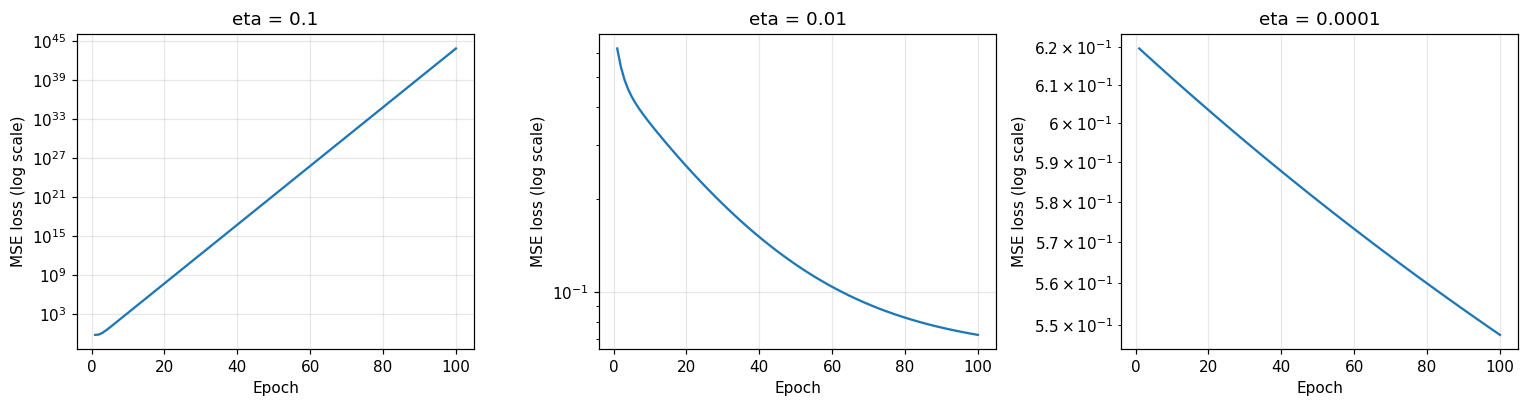

In [6]:
etas = [0.1, 0.01, 0.0001]
fig, axes = plt.subplots(1, len(etas), figsize=(14, 3.8))

for ax, eta in zip(axes, etas):
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        ada = AdalineGD(eta=eta, n_iter=100, random_state=RANDOM_STATE).fit(X_train_std, y_train)
    ax.plot(range(1, 101), ada.losses_)
    ax.set_yscale("log")
    ax.set(xlabel="Epoch", ylabel="MSE loss (log scale)", title=f"eta = {eta}")
    print(f"eta={eta:<7} final loss={ada.losses_[-1]:.4g}")
plt.tight_layout()
plt.show()

**Why does 0.1 diverge?** For MSE, gradient descent is stable only if `eta` is below roughly `1 / λ_max`, where `λ_max` is the largest eigenvalue of the feature covariance matrix. Let's check that with the actual data.

In [ ]:
lam_max = np.linalg.eigvalsh(np.cov(X_train_std, rowvar=False)).max() # compute the largest eigenvalue of the covariance matrix
print(f"lambda_max = {lam_max:.2f}  ->  stable for eta < ~{1 / lam_max:.3f}")

lambda_max = 13.45  ->  stable for eta < ~0.074


Now train the final Adaline with the stable learning rate and train longer.

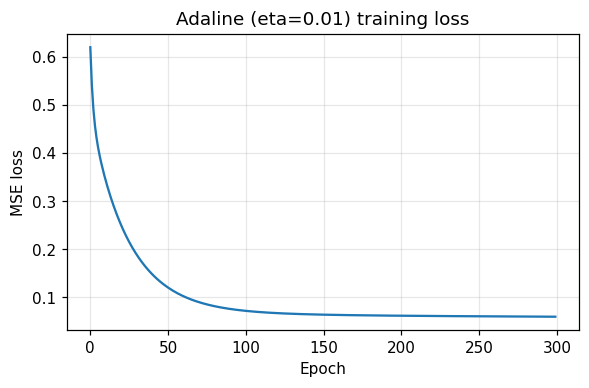

Adaline test accuracy: 0.942


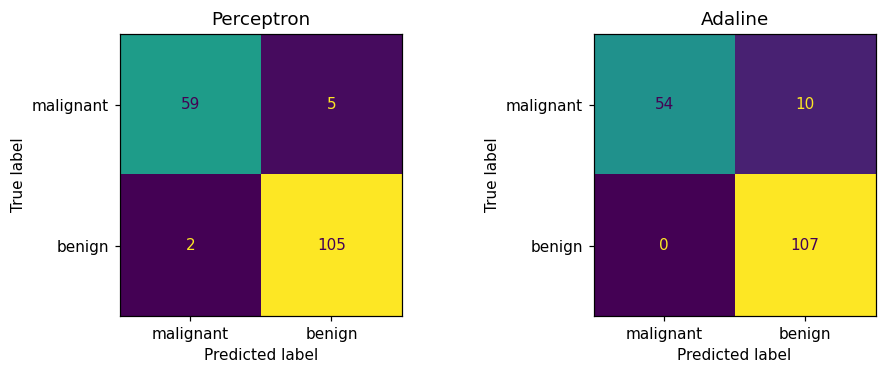

In [8]:
ada = AdalineGD(eta=0.01, n_iter=300, random_state=RANDOM_STATE).fit(X_train_std, y_train)

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.plot(ada.losses_)
ax.set(xlabel="Epoch", ylabel="MSE loss", title="Adaline (eta=0.01) training loss")
plt.show()

ada_acc = accuracy_score(y_test, ada.predict(X_test_std))
print(f"Adaline test accuracy: {ada_acc:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(9, 3.5))
for ax, model, name in zip(axes, [ppn, ada], ["Perceptron", "Adaline"]):
    ConfusionMatrixDisplay(
        confusion_matrix(y_test, model.predict(X_test_std)),
        display_labels=data.target_names,
    ).plot(ax=ax, colorbar=False)
    ax.set_title(name)
    ax.grid(False)
plt.tight_layout()
plt.show()

In a cancer-screening setting, the **malignant → predicted benign** cell (a false negative) is the costly error, so look at that cell rather than accuracy alone.

## 6. Decision boundaries on two features
With all 30 features we can't visualize the boundary, so we retrain on just `mean radius` and `mean texture` for intuition.

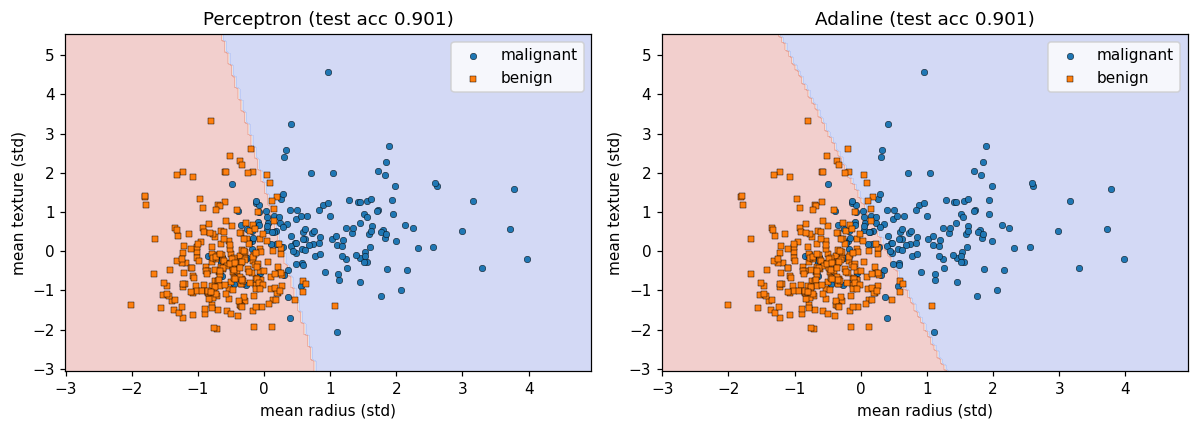

In [9]:
def plot_decision_regions(X, y, model, ax, resolution=0.05, title=""):
    x1_min, x1_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    x2_min, x2_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx1, xx2 = np.meshgrid(np.arange(x1_min, x1_max, resolution),
                           np.arange(x2_min, x2_max, resolution))
    Z = model.predict(np.c_[xx1.ravel(), xx2.ravel()]).reshape(xx1.shape)
    ax.contourf(xx1, xx2, Z, alpha=0.25, cmap="coolwarm")
    for cls, marker in zip(np.unique(y), ["o", "s"]):
        ax.scatter(X[y == cls, 0], X[y == cls, 1], marker=marker, s=18,
                   edgecolor="k", linewidth=0.3, label=data.target_names[cls])
    ax.set(xlabel="mean radius (std)", ylabel="mean texture (std)", title=title)
    ax.legend()
    ax.grid(False)

cols = [feature_names.index("mean radius"), feature_names.index("mean texture")]
X2_train, X2_test = X_train_std[:, cols], X_test_std[:, cols]

ppn2 = Perceptron(eta=0.01, n_iter=50, random_state=RANDOM_STATE).fit(X2_train, y_train)
ada2 = AdalineGD(eta=0.01, n_iter=300, random_state=RANDOM_STATE).fit(X2_train, y_train)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, m, n in zip(axes, [ppn2, ada2], ["Perceptron", "Adaline"]):
    acc = accuracy_score(y_test, m.predict(X2_test))
    plot_decision_regions(X2_train, y_train, m, ax, title=f"{n} (test acc {acc:.3f})")
plt.tight_layout()
plt.show()

## 7. Comparison with scikit-learn
A single train/test split can be misleading on a dataset this small, so we repeat the whole experiment over 20 random stratified splits and report mean ± std. Scaling is fit inside each split.

In [10]:
def make_models():
    return {
        "Majority baseline": DummyClassifier(strategy="most_frequent"),
        "Perceptron (ours)": Perceptron(eta=0.01, n_iter=50, random_state=RANDOM_STATE),
        "Adaline (ours)": AdalineGD(eta=0.01, n_iter=300, random_state=RANDOM_STATE),
        "sklearn Perceptron": SkPerceptron(eta0=0.01, max_iter=50, tol=None, random_state=RANDOM_STATE),
        "sklearn SGD (squared error)": SGDClassifier(loss="squared_error", learning_rate="constant",
                                                     eta0=0.01, max_iter=300, tol=None,
                                                     random_state=RANDOM_STATE),
        "sklearn LogisticRegression": LogisticRegression(max_iter=1000),
    }

records = []
for seed in range(20):
    Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.3, stratify=y, random_state=seed)
    scaler = StandardScaler().fit(Xtr)
    Xtr_s, Xte_s = scaler.transform(Xtr), scaler.transform(Xte)
    for name, model in make_models().items():
        pred = model.fit(Xtr_s, ytr).predict(Xte_s)
        records.append({"model": name, "seed": seed,
                        "accuracy": accuracy_score(yte, pred),
                        "f1": f1_score(yte, pred)})

results = pd.DataFrame(records)
summary = (results.groupby("model")[["accuracy", "f1"]]
           .agg(["mean", "std"]).round(4)
           .sort_values(("accuracy", "mean"), ascending=False))
summary

accuracy              f1        
                                mean     std    mean     std
model                                                       
sklearn LogisticRegression    0.9743  0.0118  0.9796  0.0092
sklearn Perceptron            0.9635  0.0139  0.9707  0.0113
Perceptron (ours)             0.9629  0.0109  0.9703  0.0089
Adaline (ours)                0.9582  0.0137  0.9676  0.0104
sklearn SGD (squared error)   0.9485  0.0251  0.9604  0.0188
Majority baseline             0.6257  0.0000  0.7698  0.0000

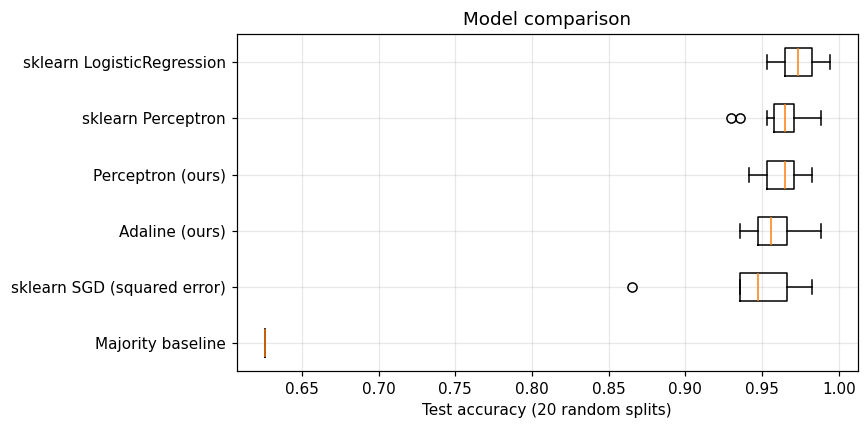

In [11]:
order = summary.index.tolist()[::-1]
fig, ax = plt.subplots(figsize=(8, 4))
ax.boxplot([results.loc[results.model == m, "accuracy"] for m in order],
           vert=False, tick_labels=order)
ax.set(xlabel="Test accuracy (20 random splits)", title="Model comparison")
plt.tight_layout()
plt.show()

## 8. Conclusions

Fill these in after you run the notebook:

- **Baseline:** majority-class accuracy is ≈ ___, so a useful model must clearly beat it.
- **Perceptron:** ___ (did the error count reach zero? what does that say about separability?).
- **Adaline:** `eta=0.1` ___, `eta=0.01` ___, `eta=0.0001` ___. This matches the stability bound `eta < 1/λ_max`.
- **Ours vs scikit-learn:** the from-scratch models score within ___ of scikit-learn's equivalents.
- **Best overall:** ___ (compare against logistic regression).
- **Error analysis:** false negatives (malignant predicted as benign) for each model: ___.

**Next steps**
- Try `AdalineSGD` (stochastic/mini-batch updates) and compare convergence speed.
- Repeat without standardization to see how badly scaling affects Adaline.
- Move on to Project 2, the classifier showdown.